# EasyOCR: распознавание текста с помощью глубокого обучения

В предыдущем блокноте мы познакомились с Tesseract  классическим OCR-движком, который отлично работает с чистыми документами. Теперь переходим к следующему уровню: **EasyOCR**.

EasyOCR это библиотека на основе глубокого обучения, которая решает две принципиально разные задачи последовательно:
1. **Детекция текста** — найти, *где* на изображении находится текст (использует CRAFT)
2. **Распознавание текста** — прочитать, *что* написано в найденных регионах (использует CRNN)

Именно разделение на два этапа делает EasyOCR намного устойчивее к сложным сценам тексту под углом, на пестром фоне, мелкому или стилизованному.

## Как устроен EasyOCR?


### Этап 1: Детекция (CRAFT)

CRAFT (Character Region Awareness for Text Detection) — нейросеть на базе VGG-16, которая строит две тепловые карты:
- **Region score** — вероятность того, что в данной точке находится центр символа
- **Affinity score** — вероятность того, что два соседних символа образуют одно слово

Из этих карт алгоритм собирает bounding box вокруг каждого слова или строки текста.


### Этап 2: Распознавание (CRNN)

Найденные регионы вырезаются, выпрямляются и подаются в CRNN:
- **CNN** (ResNet) — извлекает визуальные признаки из картинки со словом
- **RNN** (LSTM) — читает признаки как последовательность, слева направо
- **CTC** (Connectionist Temporal Classification) — декодирует последовательность в текст без явной разметки позиций букв



### Поддержка языков
EasyOCR поддерживает 80+ языков. Для каждого языка или группы языков скачивается отдельная модель распознавания, при этом детектор (CRAFT) один для всех.

В этом блокноте мы:
1. Установим EasyOCR и разберемся с его API
2. Распознаем текст на простом изображении
3. Поработаем с многоязычным текстом
4. Попробуем распознать чек
5. Разберем параметры детекции и их влияние на результат
6. Сравним EasyOCR и Tesseract на одних и тех же изображениях

Полезные ссылки:
- [Документация EasyOCR](https://www.jaided.ai/easyocr/documentation/)
- [GitHub репозиторий](https://github.com/JaidedAI/EasyOCR)
- [Список поддерживаемых языков](https://www.jaided.ai/easyocr/)

## Установка

EasyOCR устанавливается одной командой. При первом запуске он автоматически скачает нужные модели (~100 MB для детектора + модель для каждого языка).


In [ ]:
!pip install -q easyocr opencv-python matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 10.6 MB/s eta 0:00:00


Установим шрифт с поддержкой кириллицы:

In [ ]:
!apt-get update -qq
!apt-get install -qq fonts-dejavu fonts-liberation

# Проверка установленных шрифтов
!fc-list | grep -i dejavu | head -5

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-dejavu-core.
(Reading database ... 118198 files and directories currently installed.)
Preparing to unpack .../fonts-dejavu-core_2.37-2build1_all.deb ...
Unpacking fonts-dejavu-core (2.37-2build1) ...
Selecting previously unselected package fonts-dejavu-extra.
Preparing to unpack .../fonts-dejavu-extra_2.37-2build1_all.deb ...
Unpacking fonts-dejavu-extra (2.37-2build1) ...
Selecting previously unselected package fonts-dejavu.
Preparing to unpack .../fonts-dejavu_2.37-2build1_all.deb ...
Unpacking fonts-dejavu (2.37-2build1) ...
Setting up fonts-dejavu-core (2.37-2build1) ...
Setting up fonts-dejavu-extra (2.37-2build1) ...
Setting up fonts-dejavu (2.37-2build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts/truetype/dejavu

In [ ]:
import easyocr
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import urllib.request
from pathlib import Path

print(f"EasyOCR version: {easyocr.__version__}")

EasyOCR version: 1.7.2


In [ ]:
import warnings
warnings.filterwarnings('ignore', message='.*pin_memory.*')

## Создание Reader

`easyocr.Reader` — главный объект библиотеки. При создании он:
1. Скачивает модель детектора CRAFT (один раз)
2. Скачивает модели распознавания для указанных языков
3. Загружает всё в память (или на GPU если доступен)

Параметр `gpu=True` значительно ускоряет работу, но в Colab на CPU тоже работает нормально для небольших изображений.

**Важно:** список языков задается один раз при создании Reader. Если нужно добавить язык то нужно пересоздать Reader.

In [ ]:
reader = easyocr.Reader(
    ['ru', 'en'],
    gpu=False,
    recog_network='standard',  # явно указываем стандартную модель распознавания
    download_enabled=True
)

## Первый запуск: простое изображение

Начнем с синтетического изображения создадим его программно, чтобы точно знать правильный ответ.

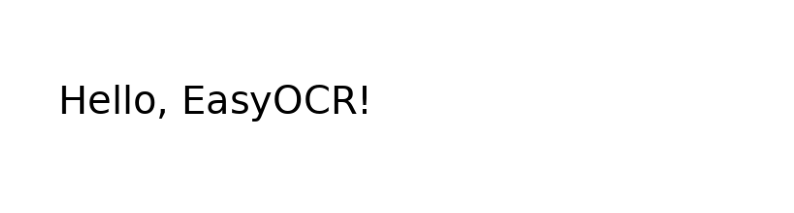

In [ ]:
# Создаём простое изображение с текстом
img = Image.new('RGB', (800, 200), color='white')
draw = ImageDraw.Draw(img)

font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 40)

draw.text((50, 70), "Hello, EasyOCR!", fill='black', font=font)
img.save('simple.png')

plt.figure(figsize=(10, 3))
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
# Распознаём текст
results = reader.readtext('simple.png')

print("Результат readtext():")
for bbox, text, confidence in results:
    print(f"  Текст: '{text}'")
    print(f"  Уверенность: {confidence:.2%}")
    print(f"  Координаты bbox: {bbox}")
    print()

Результат readtext():
  Текст: 'Hello, EasyOCR!'
  Уверенность: 78.03%
  Координаты bbox: [[np.int32(43), np.int32(66)], [np.int32(379), np.int32(66)], [np.int32(379), np.int32(126)], [np.int32(43), np.int32(126)]]




Каждый элемент результата это кортеж из трех элементов:
- **bbox** — список из 4 точек `[[x1,y1], [x2,y2], [x3,y3], [x4,y4]]` — углы прямоугольника по часовой стрелке
- **text** — распознанный текст
- **confidence** — уверенность модели от 0 до 1

Bbox задается четырьмя точками (а не `x, y, w, h`), что позволяет корректно описывать наклоненные боксы.

## Визуализация результатов

Напишем вспомогательную функцию для визуализации она пригодится во всех следующих экспериментах.

In [ ]:
def visualize_results(image_path, results,font=font, title='EasyOCR результат', figsize=(12, 8)):
    """Отрисовывает bbox и текст поверх изображения."""
    img = cv2.imread(image_path) if isinstance(image_path, str) else image_path
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if len(img.shape) == 3 else img

    # Переходим в PIL для рисования — он поддерживает Unicode/кириллицу
    pil_img = Image.fromarray(img_rgb)
    draw    = ImageDraw.Draw(pil_img)


    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 16)

    for bbox, text, conf in results:
        pts   = np.array(bbox, dtype=np.int32)
        color = (0, int(255 * conf), int(255 * (1 - conf)))
        text_color = (148, 0, 211)
        # Рисуем bbox через cv2 на numpy-массиве, потом конвертируем обратно
        vis_np = np.array(pil_img)
        cv2.polylines(vis_np, [pts], isClosed=True, color=color, thickness=2)
        pil_img = Image.fromarray(vis_np)
        draw    = ImageDraw.Draw(pil_img)

        # Подпись через PIL — поддерживает кириллицу
        label  = f"{text} ({conf:.0%})"
        x, y   = pts[0]
        draw.text((x, max(y - 20, 0)), label, fill=text_color, font=font)

    plt.figure(figsize=figsize)
    plt.imshow(pil_img)
    plt.axis('off')
    plt.title(title)
    plt.tight_layout()
    plt.show()

## Многоязычное распознавание

Одно из главных преимуществ EasyOCR это одновременная работа с несколькими языками на одном изображении. Tesseract для этого требует передавать языки через `+`, и всё равно иногда путается. EasyOCR работает с этим нативно.

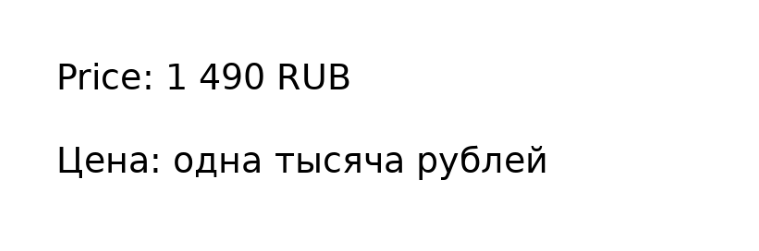

In [ ]:
# Создаём двуязычное изображение
img = Image.new('RGB', (800, 250), color='white')
draw = ImageDraw.Draw(img)

font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 38)

draw.text((50, 50),  "Price: 1 490 RUB",          fill='black', font=font)
draw.text((50, 140), "Цена: одна тысяча рублей",   fill='black', font=font)
img.save('multilang.png')

plt.figure(figsize=(10, 3))
plt.imshow(img)
plt.axis('off')
plt.show()

Распознанный текст:
  'Price:' — 100.00%
  '1 490 RUB' — 94.01%
  'Цена: одна тысяча' — 99.87%
  'рублей' — 100.00%


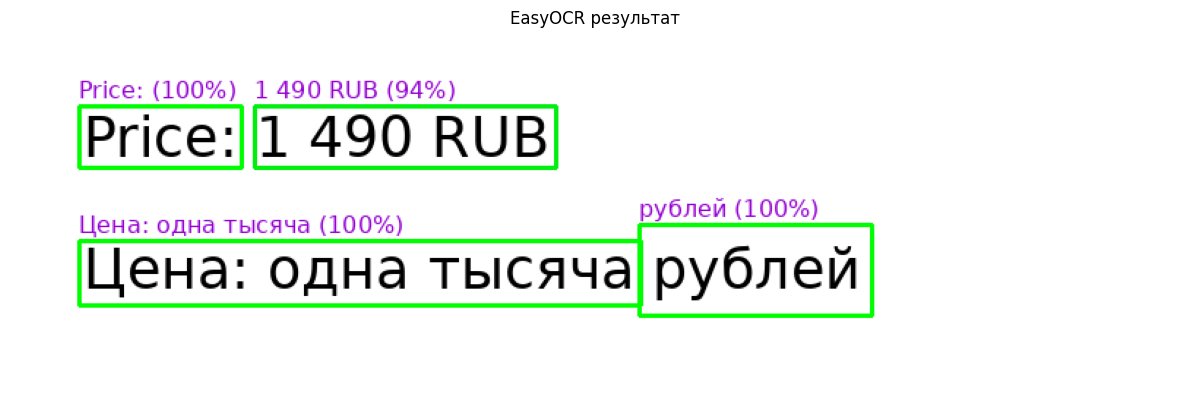

In [ ]:
results = reader.readtext('multilang.png')

print("Распознанный текст:")
for bbox, text, conf in results:
    print(f"  '{text}' — {conf:.2%}")

visualize_results('multilang.png', results, 'Многоязычное распознавание (EN + RU)')

## Реальные сценарии

Посмотрим как EasyOCR справляется с задачами, которые встречаются на практике.

Создадим синтетический чек

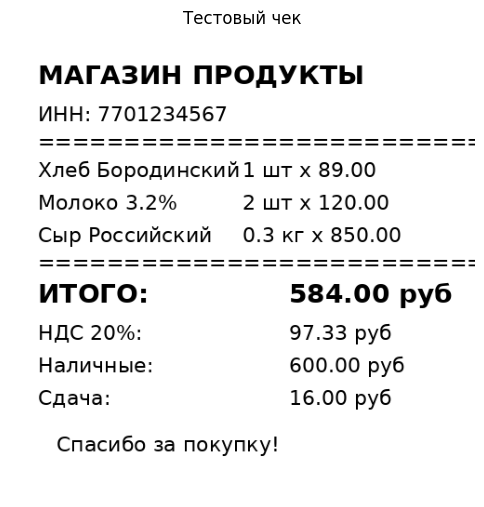

In [ ]:
# Создаём синтетический чек
img = Image.new('RGB', (500, 500), color='white')
draw = ImageDraw.Draw(img)

font_large = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 28)
font_small = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 22)

lines = [
    ("МАГАЗИН ПРОДУКТЫ",  30,  30, font_large),
    ("ИНН: 7701234567",   30,  75, font_small),
    ("="*35,              30, 105, font_small),
    ("Хлеб Бородинский",  30, 135, font_small),
    ("1 шт x 89.00",     250, 135, font_small),
    ("Молоко 3.2%",       30, 170, font_small),
    ("2 шт x 120.00",    250, 170, font_small),
    ("Сыр Российский",    30, 205, font_small),
    ("0.3 кг x 850.00",  250, 205, font_small),
    ("="*35,              30, 235, font_small),
    ("ИТОГО:",            30, 265, font_large),
    ("584.00 руб",       300, 265, font_large),
    ("НДС 20%:",          30, 310, font_small),
    ("97.33 руб",        300, 310, font_small),
    ("Наличные:",         30, 345, font_small),
    ("600.00 руб",       300, 345, font_small),
    ("Сдача:",            30, 380, font_small),
    ("16.00 руб",        300, 380, font_small),
    ("Спасибо за покупку!", 50, 430, font_small),
]

for text, x, y, font in lines:
    draw.text((x, y), text, fill='black', font=font)

img.save('receipt.png')

plt.figure(figsize=(6, 7))
plt.imshow(img)
plt.axis('off')
plt.title('Тестовый чек')
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Найдено текстовых регионов: 20

Распознанный текст:
  [99%] МАГАЗИН ПРОДУКТЫ
  [79%] ИНН: 7701234567
  [0%] 
  [78%] Хлеб Бородинский 1
  [83%] шт x 89.00
  [100%] Молоко 3.2%
  [57%] 2 шт x 120.00
  [75%] Сыр Российский
  [56%] 0.3 кг x 850.00
  [19%] иТОГО:
  [68%] 584.00
  [96%] НДС 20%:
  [92%] 97.33 руб
  [94%] Наличные
  [99%] 600.00 руб
  [100%] Сдача
  [98%] 16.00
  [99%] Спасибо за покупку!
  [95%] руб
  [100%] руб


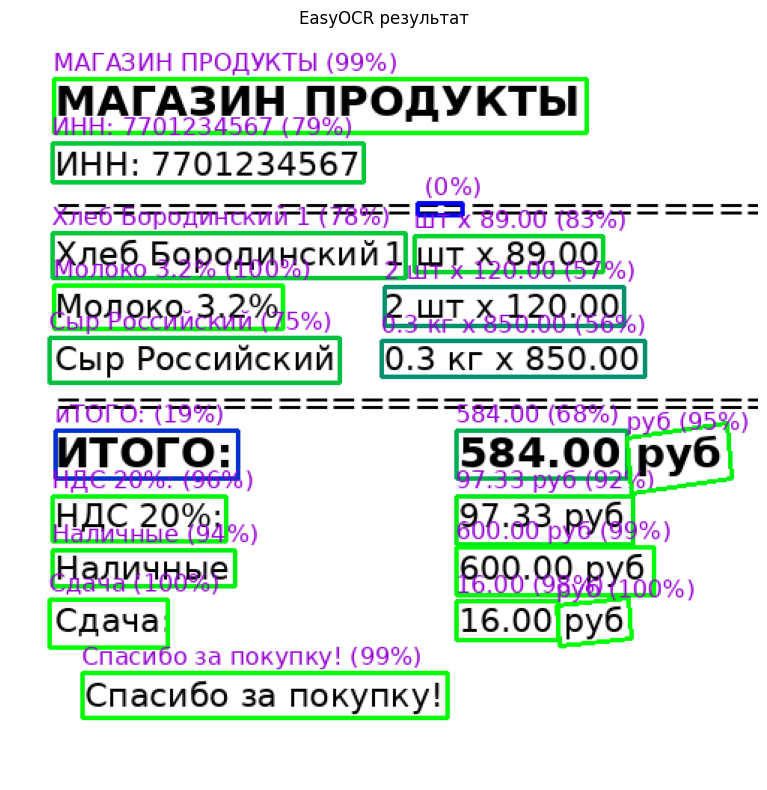

In [ ]:
results = reader.readtext('receipt.png')

print(f"Найдено текстовых регионов: {len(results)}\n")
print("Распознанный текст:")
for bbox, text, conf in results:
    print(f"  [{conf:.0%}] {text}")

visualize_results('receipt.png', results, f'Чек: {len(results)} регионов')

## Параметры детекции и их влияние

У `readtext()` есть несколько ключевых параметров, которые напрямую влияют на результат:

| Параметр | По умолчанию | Описание |
|---|---|---|
| `detail` | 1 | 0 = только текст, 1 = текст + bbox + confidence |
| `paragraph` | False | Объединять соседние боксы в абзацы |
| `min_size` | 10 | Минимальный размер текстового региона в пикселях |
| `text_threshold` | 0.7 | Порог уверенности распознавания |
| `low_text` | 0.4 | Нижний порог для region score детектора |
| `link_threshold` | 0.4 | Порог affinity score для объединения символов в слова |
| `width_ths` | 0.5 | Порог для объединения боксов по горизонтали |
| `slope_ths` | 0.1 | Допустимый наклон строки для объединения |

Разберем самые важные из них.

In [ ]:
# detail=0 возвращает только список строк — удобно для быстрого извлечения текста
texts_only = reader.readtext('receipt.png', detail=0)
print("detail=0 (только текст):")
print(texts_only)
print()

# detail=1 возвращает полные данные (по умолчанию)
full_results = reader.readtext('receipt.png', detail=1)
print(f"detail=1 (полные данные): {len(full_results)} элементов")
print(f"1 объект: {full_results[0]}")

detail=0 (только текст):
['МАГАЗИН ПРОДУКТЫ', 'ИНН: 7701234567', '', 'Хлеб Бородинский 1', 'шт x 89.00', 'Молоко 3.2%', '2 шт x 120.00', 'Сыр Российский', '0.3 кг x 850.00', 'иТОГО:', '584.00', 'НДС 20%:', '97.33 руб', 'Наличные', '600.00 руб', 'Сдача', '16.00', 'Спасибо за покупку!', 'руб', 'руб']

detail=1 (полные данные): 20 элементов
1 объект:
([[np.int32(29), np.int32(31)], [np.int32(385), np.int32(31)], [np.int32(385), np.int32(67)], [np.int32(29), np.int32(67)]], 'МАГАЗИН ПРОДУКТЫ', np.float64(0.9940282694674213))


In [ ]:
# paragraph=True объединяет соседние боксы в абзацы
# Полезно когда нужно сохранить структуру документа

results_para = reader.readtext('receipt.png', paragraph=True)
results_word = reader.readtext('receipt.png', paragraph=False)

print(f"paragraph=False: {len(results_word)} регионов")
print(f"paragraph=True:  {len(results_para)} регионов")
print()
print("Текст с paragraph=True:")
for bbox, text in results_para:
    print(f"  '{text}'")

paragraph=False: 20 регионов
paragraph=True:  5 регионов

Текст с paragraph=True:
  'МАГАЗИН ПРОДУКТЫ ИНН: 7701234567 '
  'Хлеб Бородинский 1 шт x 89.00 Молоко 3.2% 2 шт x 120.00 Сыр Российский 0.3 кг x 850.00'
  'иТОГО: НДС 20%: Наличные Сдача'
  '584.00 руб 97.33 руб 600.00 руб 16.00 руб'
  'Спасибо за покупку!'


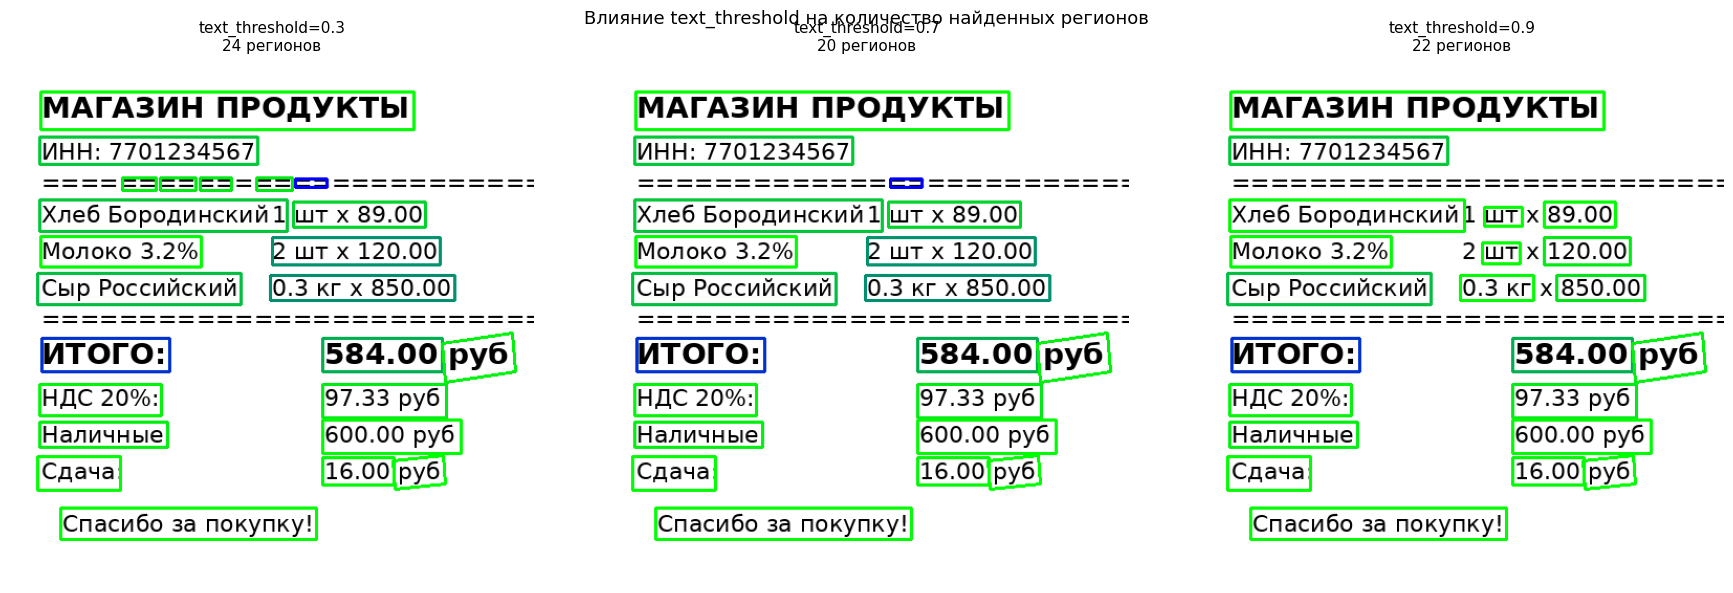

In [ ]:
# Сравниваем разные пороги text_threshold
# Высокий порог — меньше результатов, но выше точность
# Низкий порог — больше результатов, но могут появиться ложные срабатывания

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

img_bgr = cv2.imread('receipt.png')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

for ax, thresh in zip(axes, [0.3, 0.7, 0.9]):
    results_t = reader.readtext('receipt.png', text_threshold=thresh)
    vis = img_rgb.copy()

    for bbox, text, conf in results_t:
        pts = np.array(bbox, dtype=np.int32)
        color = (0, int(255 * conf), int(255 * (1 - conf)))
        cv2.polylines(vis, [pts], True, color, 2)

    ax.imshow(vis)
    ax.set_title(f'text_threshold={thresh}\n{len(results_t)} регионов', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Предобработка изображений

EasyOCR значительно устойчивее к "грязным" изображениям чем Tesseract, но предобработка все равно помогает в сложных случаях.

Рассмотрим простой, но показательный пример

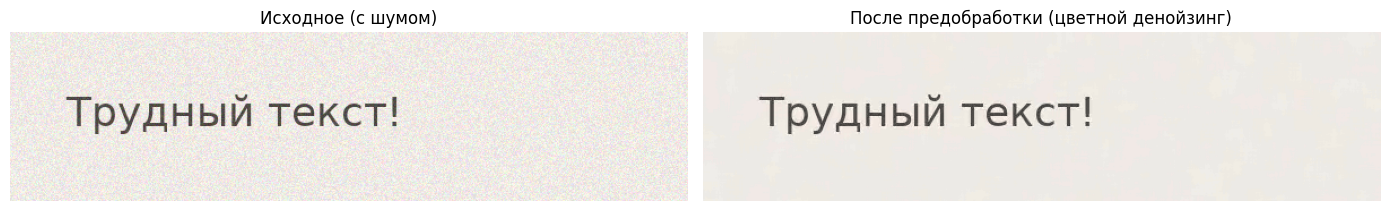

In [ ]:
# Добавляем шум
noise = np.random.randint(0, 40, img_array.shape, dtype=np.uint8)
noisy = np.clip(img_array.astype(np.int32) + noise - 20, 0, 255).astype(np.uint8)
cv2.imwrite('noisy.png', cv2.cvtColor(noisy, cv2.COLOR_RGB2BGR))

# Предобработка: денойзинг в цвете + билатеральный фильтр (сохраняет края)
denoised_color = cv2.fastNlMeansDenoisingColored(
    cv2.cvtColor(noisy, cv2.COLOR_RGB2BGR),
    h=10, hColor=10,          # h — сила денойзинга (меньше = аккуратнее)
    templateWindowSize=7,
    searchWindowSize=21
)
enhanced = cv2.cvtColor(denoised_color, cv2.COLOR_BGR2RGB)
cv2.imwrite('enhanced.png', cv2.cvtColor(enhanced, cv2.COLOR_RGB2BGR))

# Визуализируем до/после
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(noisy)
axes[0].set_title('Исходное (с шумом)')
axes[0].axis('off')
axes[1].imshow(enhanced)
axes[1].set_title('После предобработки (цветной денойзинг)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Сравниваем результаты до и после предобработки
results_noisy    = reader.readtext('noisy.png')
results_enhanced = reader.readtext('enhanced.png')

print("Без предобработки:")
for _, text, conf in results_noisy:
    print(f"  [{conf:.0%}] {text}")

print()
print("После предобработки:")
for _, text, conf in results_enhanced:
    print(f"  [{conf:.0%}] {text}")

Без предобработки:
  [76%] Трудный текст!

После предобработки:
  [98%] Трудный текст!


## Анализ уверенности распознавания

Confidence score в EasyOCR это вероятность, которую выдает CRNN-модель для распознанного текста. Он полезен для:
- Фильтрации ложных срабатываний
- Принятия решения о необходимости ручной проверки
- Оценки качества исходного изображения

Статистика уверенности:
  Средняя:      79.4%
  Минимальная:  0.0%
  Максимальная: 100.0%


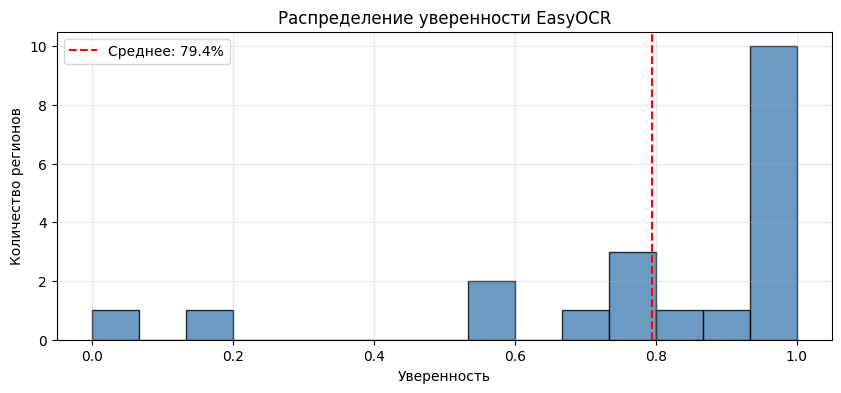


Регионы с уверенностью < 80%:
  'ИНН: 7701234567' — 78.6%
  '' — 0.0%
  'Хлеб Бородинский 1' — 78.4%
  '2 шт x 120.00' — 57.0%
  'Сыр Российский' — 74.6%
  '0.3 кг x 850.00' — 56.5%
  'иТОГО:' — 19.2%
  '584.00' — 68.3%


In [ ]:
results = reader.readtext('receipt.png')

confidences = [conf for _, _, conf in results]
texts       = [text for _, text, _ in results]

if confidences:
    print(f"Статистика уверенности:")
    print(f"  Средняя:      {np.mean(confidences):.1%}")
    print(f"  Минимальная:  {np.min(confidences):.1%}")
    print(f"  Максимальная: {np.max(confidences):.1%}")

    # Гистограмма
    plt.figure(figsize=(10, 4))
    plt.hist(confidences, bins=15, edgecolor='black', color='steelblue', alpha=0.8)
    plt.axvline(np.mean(confidences), color='red', linestyle='--',
                label=f'Среднее: {np.mean(confidences):.1%}')
    plt.xlabel('Уверенность')
    plt.ylabel('Количество регионов')
    plt.title('Распределение уверенности EasyOCR')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Регионы с низкой уверенностью
    threshold = 0.8
    low_conf  = [(text, conf) for text, conf in zip(texts, confidences) if conf < threshold]
    if low_conf:
        print(f"\nРегионы с уверенностью < {threshold:.0%}:")
        for text, conf in low_conf:
            print(f"  '{text}' — {conf:.1%}")

## Сравнение EasyOCR vs Tesseract

Сравним оба инструмента на одном и том же изображении, чтобы наглядно увидеть их сильные и слабые стороны.

In [ ]:
!apt-get install -q tesseract-ocr tesseract-ocr-rus
!pip install -q pytesseract
import pytesseract

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-rus
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 1,271 kB of archives.
After this operation, 3,877 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-rus all 1:4.00~git30-7274cfa-1.1 [1,271 kB]
Fetched 1,271 kB in 1s (1,020 kB/s)
Selecting previously unselected package tesseract-ocr-rus.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-rus_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-rus (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-rus (1:4.00~git30-7274cfa-1.1) ...


In [ ]:
# Тест 1: чистый документ — здесь Tesseract в своей стихии
image_path = 'receipt.png'

# EasyOCR
easy_results = reader.readtext(image_path, detail=0)
easy_text    = ' '.join(easy_results)

# Tesseract
tess_text = pytesseract.image_to_string(
    Image.open(image_path), lang='rus', config='--psm 6'
).strip()

print("=" * 50)
print("EasyOCR:")
print(easy_text)
print()
print("=" * 50)
print("Tesseract:")
print(tess_text)

EasyOCR:
МАГАЗИН ПРОДУКТЫ ИНН: 7701234567  Хлеб Бородинский 1 шт x 89.00 Молоко 3.2% 2 шт x 120.00 Сыр Российский 0.3 кг x 850.00 иТОГО: 584.00 НДС 20%: 97.33 руб Наличные 600.00 руб Сдача 16.00 Спасибо за покупку! руб руб

Tesseract:
МАГАЗИН ПРОДУКТЫ

ИНН: 7701234567

Хлеб Бородинский1 штх 89.00

Молоко 3.2% 2 штх 120.00

Сыр Российский 0.3 кгх 850.00

ИТОГО: 584.00 руб

НДС 20%: 97.33 руб

Наличные: 600.00 руб

Сдача: 16.00 руб
Спасибо за покупку!


Наклоненный текст (15 градусов):
  EasyOCR:   ['Rotated', 'text', 'sample']
  Tesseract: ''


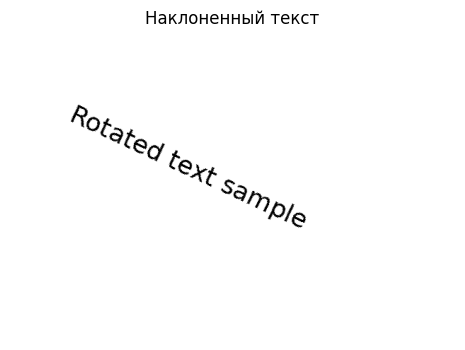

In [ ]:
# Тест 2: текст под углом — здесь EasyOCR значительно лучше
img = Image.new('RGB', (600, 200), color='white')
draw = ImageDraw.Draw(img)


draw.text((50, 80), "Rotated text sample", fill='black', font=font)
img_rotated = img.rotate(335, expand=True, fillcolor='white')
img_rotated.save('rotated.png')

# EasyOCR
easy_rot = reader.readtext('rotated.png', detail=0)
# Tesseract
tess_rot = pytesseract.image_to_string(img_rotated, lang='eng').strip()

print("Наклоненный текст (335 градусов):")
print(f"  EasyOCR:   {easy_rot}")
print(f"  Tesseract: {repr(tess_rot)}")

plt.figure(figsize=(8, 4))
plt.imshow(img_rotated)
plt.axis('off')
plt.title('Наклоненный текст')
plt.show()

Правда если мы изменим угол поврота то всплывет ограничение EasyOCR при наклоне детектор (CRAFT) иногда находит слова как отдельные боксы в порядке уверенности, а не слева направо.

Наклоненный текст (25 градусов):
  EasyOCR:   ['sample', 'text', 'Rotated']


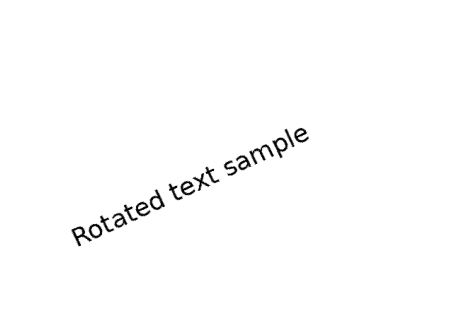

In [ ]:
img = Image.new('RGB', (600, 200), color='white')
draw = ImageDraw.Draw(img)

draw.text((50, 80), "Rotated text sample", fill='black', font=font)
img_rotated = img.rotate(25, expand=True, fillcolor='white')
img_rotated.save('rotated.png')

easy_rot = reader.readtext('rotated.png', detail=0)

print("Наклоненный текст (25 градусов):")
print(f"  EasyOCR:   {easy_rot}")

plt.figure(figsize=(8, 4))
plt.imshow(img_rotated)
plt.axis('off')
plt.show()

Восстановить правильный порядок можно сортировкой по координатам:

In [ ]:
def sort_along_text_direction(results):
    if len(results) < 2:
        return results

    centers = np.array([np.array(r[0]).mean(axis=0) for r in results])
    centered = centers - centers.mean(axis=0)
    _, _, vt  = np.linalg.svd(centered)
    direction = vt[0]

    # Если вектор направлен влево — инвертируем
    if direction[0] < 0:
        direction = -direction

    projections = centers @ direction
    return [r for _, r in sorted(zip(projections, results), key=lambda x: x[0])]


print("До сортировки:")
print([text for _, text, _ in results_rotated])

results_sorted = sort_along_text_direction(results_rotated)

print("После сортировки:")
print([text for _, text, _ in results_sorted])

До сортировки:
['sample', 'text', 'Rotated']
После сортировки:
['Rotated', 'text', 'sample']


## Ограничения EasyOCR

**Когда EasyOCR хорош:**
- Текст на фотографиях из реального мира (вывески, чеки, бейджи)
- Наклоненный или повернутый текст
- Многоязычные изображения
- Текст на сложном фоне
- Быстрый старт без настройки

**Когда EasyOCR проигрывает:**
- Очень длинные документы (медленнее Tesseract без GPU)
- Сложная структура страницы: таблицы, колонки, формулы т.к нет встроенного layout-анализа
- Рукописный текст тут как и Tesseract, не обучен на нем
- Нестандартные шрифты, которых нет в обучающих данных


## Заключение

Главные выводы:

1. **EasyOCR = детекция + распознавание.** Разделение на два этапа (CRAFT + CRNN) дает гибкость: детектор находит текст в сложных условиях, а распознаватель читает каждый найденный регион независимо.

2. **Параметры детекции важны.** `text_threshold`, `low_text` и `link_threshold` контролируют баланс между полнотой и точностью. Для документов поднимайте пороги, для сложных сцен опускайте.

3. **EasyOCR не заменяет Tesseract полностью.** Для чистых печатных документов Tesseract быстрее и не требует GPU. EasyOCR выигрывает там, где текст находится в болле сложной сцене.

4. **Предобработка все еще помогает.** Даже мощная нейросеть работает лучше с качественным входом. Денойзинг и нормализация контраста повышают уверенность распознавания.

В следующем блокноте рассмотрим PaddleOCR промышленное решение от Baidu с поддержкой DB-Net детектора и рекордной скоростью на мобильных устройствах.

**Полезные ресурсы:**
- [EasyOCR GitHub](https://github.com/JaidedAI/EasyOCR)
